In [ ]:
import os
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
#---------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
#---------------------------------------
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Accuracy,Precision, Recall
from tensorflow.keras.layers import Dense, Dropout, Flatten,BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#---------------------------------------
import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully!")
print("TensorFlow Version:", tf.__version__)

Libraries Imported Successfully!
TensorFlow Version: 2.20.0


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
base_path = "/content/drive/MyDrive"

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/Brain_Tumor_MRI_Project"

TRAIN_PATH = os.path.join(DATASET_PATH, "Training")
TEST_PATH = os.path.join(DATASET_PATH, "Testing")


In [ ]:
print(os.listdir(DATASET_PATH))

['Training', 'Testing']


<pre>
Brain Tumor Dataset/
│
├── Training/
│   ├── glioma/
│   ├── meningioma/
│   ├── pituitary/
│   └── notumor/
│
└── Testing/
    ├── glioma/
    ├── meningioma/
    ├── pituitary/
    └── notumor/
</pre>


In [ ]:
TRAIN_PATH = os.path.join(DATASET_PATH, "Training")
TEST_PATH = os.path.join(DATASET_PATH, "Testing")

print("Train:")
print(os.listdir(TRAIN_PATH))
print("------------------------------------------------")
print("Test:")
print(os.listdir(TEST_PATH))

Train:
['meningioma', 'notumor', 'glioma', 'pituitary']
------------------------------------------------
Test:
['glioma', 'notumor', 'meningioma', 'pituitary']


In [ ]:
IMG_SIZE = (224, 224)
IMG_SHAPE =(224,224,3)

BATCH_SIZE = 32
SEED = 42
NUM_CLASSES = 4

In [ ]:
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
# --------------------------------------------------------------- #
def LoadData(path):
    Dataset = []

    for class_name in os.listdir(path):

        class_path = os.path.join(path, class_name)

        if os.path.isdir(class_path):

            for img_name in os.listdir(class_path):

                if img_name.lower().endswith(IMAGE_EXTENSIONS):

                    image_path = os.path.join(
                        class_path,
                        img_name
                    )

                    Dataset.append({
                        "Class Path": image_path,
                        "Class": class_name
                    })

    return pd.DataFrame(Dataset)


In [ ]:
# Load Data
Training = LoadData(TRAIN_PATH)
Testing = LoadData(TEST_PATH)

In [ ]:
# Check Data
print("Train Shape:", Training.shape)
print("Test Shape:", Testing.shape)

Train Shape: (5600, 2)
Test Shape: (1600, 2)


In [ ]:
# Display samples
Training.head()


,Class Path,Class
0,/content/drive/MyDrive/Brain_Tumor_MRI_Project...,meningioma
1,/content/drive/MyDrive/Brain_Tumor_MRI_Project...,meningioma
2,/content/drive/MyDrive/Brain_Tumor_MRI_Project...,meningioma
3,/content/drive/MyDrive/Brain_Tumor_MRI_Project...,meningioma
4,/content/drive/MyDrive/Brain_Tumor_MRI_Project...,meningioma


In [ ]:
Testing.head()

,Class Path,Class
0,/content/drive/MyDrive/Brain_Tumor_MRI_Project...,glioma
1,/content/drive/MyDrive/Brain_Tumor_MRI_Project...,glioma
2,/content/drive/MyDrive/Brain_Tumor_MRI_Project...,glioma
3,/content/drive/MyDrive/Brain_Tumor_MRI_Project...,glioma
4,/content/drive/MyDrive/Brain_Tumor_MRI_Project...,glioma


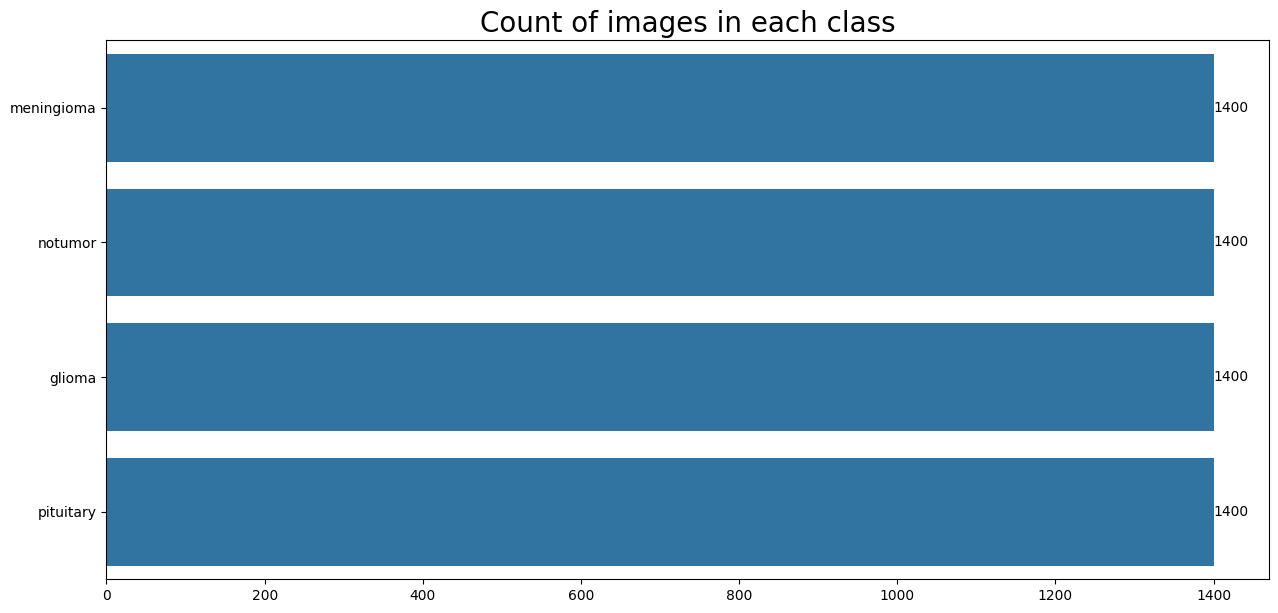

In [ ]:
# Count of images in each class in train data
plt.figure(figsize=(15,7))
ax = sns.countplot(data=Training , y=Training['Class'])

plt.xlabel('')
plt.ylabel('')
plt.title('Count of images in each class', fontsize=20)
ax.bar_label(ax.containers[0])
plt.show()

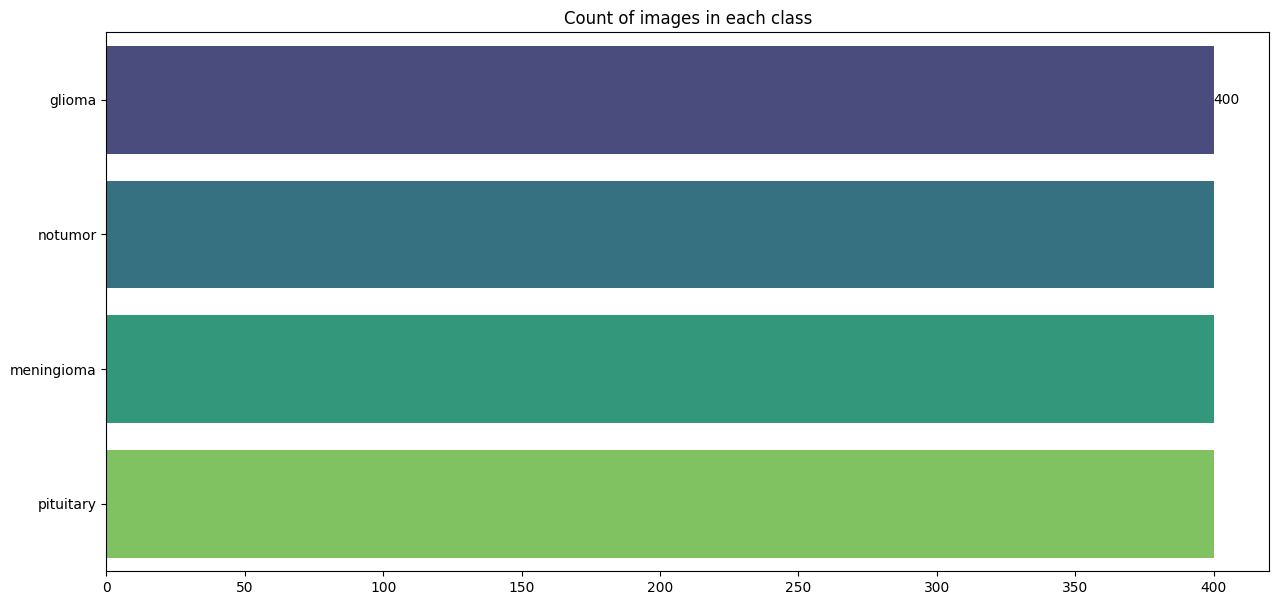

In [ ]:
#Count each class in test data
plt.figure(figsize=(15, 7))
ax = sns.countplot(data=Testing,y=Testing['Class'], palette='viridis')

ax.set(xlabel='', ylabel='', title='Count of images in each class')
ax.bar_label(ax.containers[0])
plt.show()

In [ ]:
Validing,Testing = train_test_split(
    Testing,
    test_size=0.5,
    random_state=42,
    stratify=Testing["Class"],
    shuffle=True
)

print("Training:", Training.shape)
print("Validation:", Validing.shape)
print("Testing:", Testing.shape)

Training: (5600, 2)
Validation: (800, 2)
Testing: (800, 2)


In [ ]:
# Data Generation
# ---------------------------------#
_Generation = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.10,
    shear_range=0.10,
    horizontal_flip=True,
    fill_mode='nearest'
)
# ---------------------------------#
Test_Generation = ImageDataGenerator(
    rescale=1./255
   )

# ---------------------------------#
# Training Generator
# ---------------------------------#

NewTraining_gen = _Generation.flow_from_dataframe(
    dataframe=Training,
    x_col="Class Path",
    y_col="Class",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)
# ---------------------------------#

NewValiding_gen = Test_Generation.flow_from_dataframe(
    dataframe=Validing,
    x_col="Class Path",
    y_col="Class",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)
# ---------------------------------#
NewTesting_gen = Test_Generation.flow_from_dataframe(
    dataframe=Testing,
    x_col="Class Path",
    y_col="Class",
    target_size=IMG_SIZE,
    batch_size=16,
    class_mode="categorical",
    shuffle=False
)

Found 5600 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.


In [ ]:
print("Class Indices:", NewTraining_gen.class_indices)

Class Indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [ ]:
print("Class Indices:", NewTesting_gen.class_indices)

Class Indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


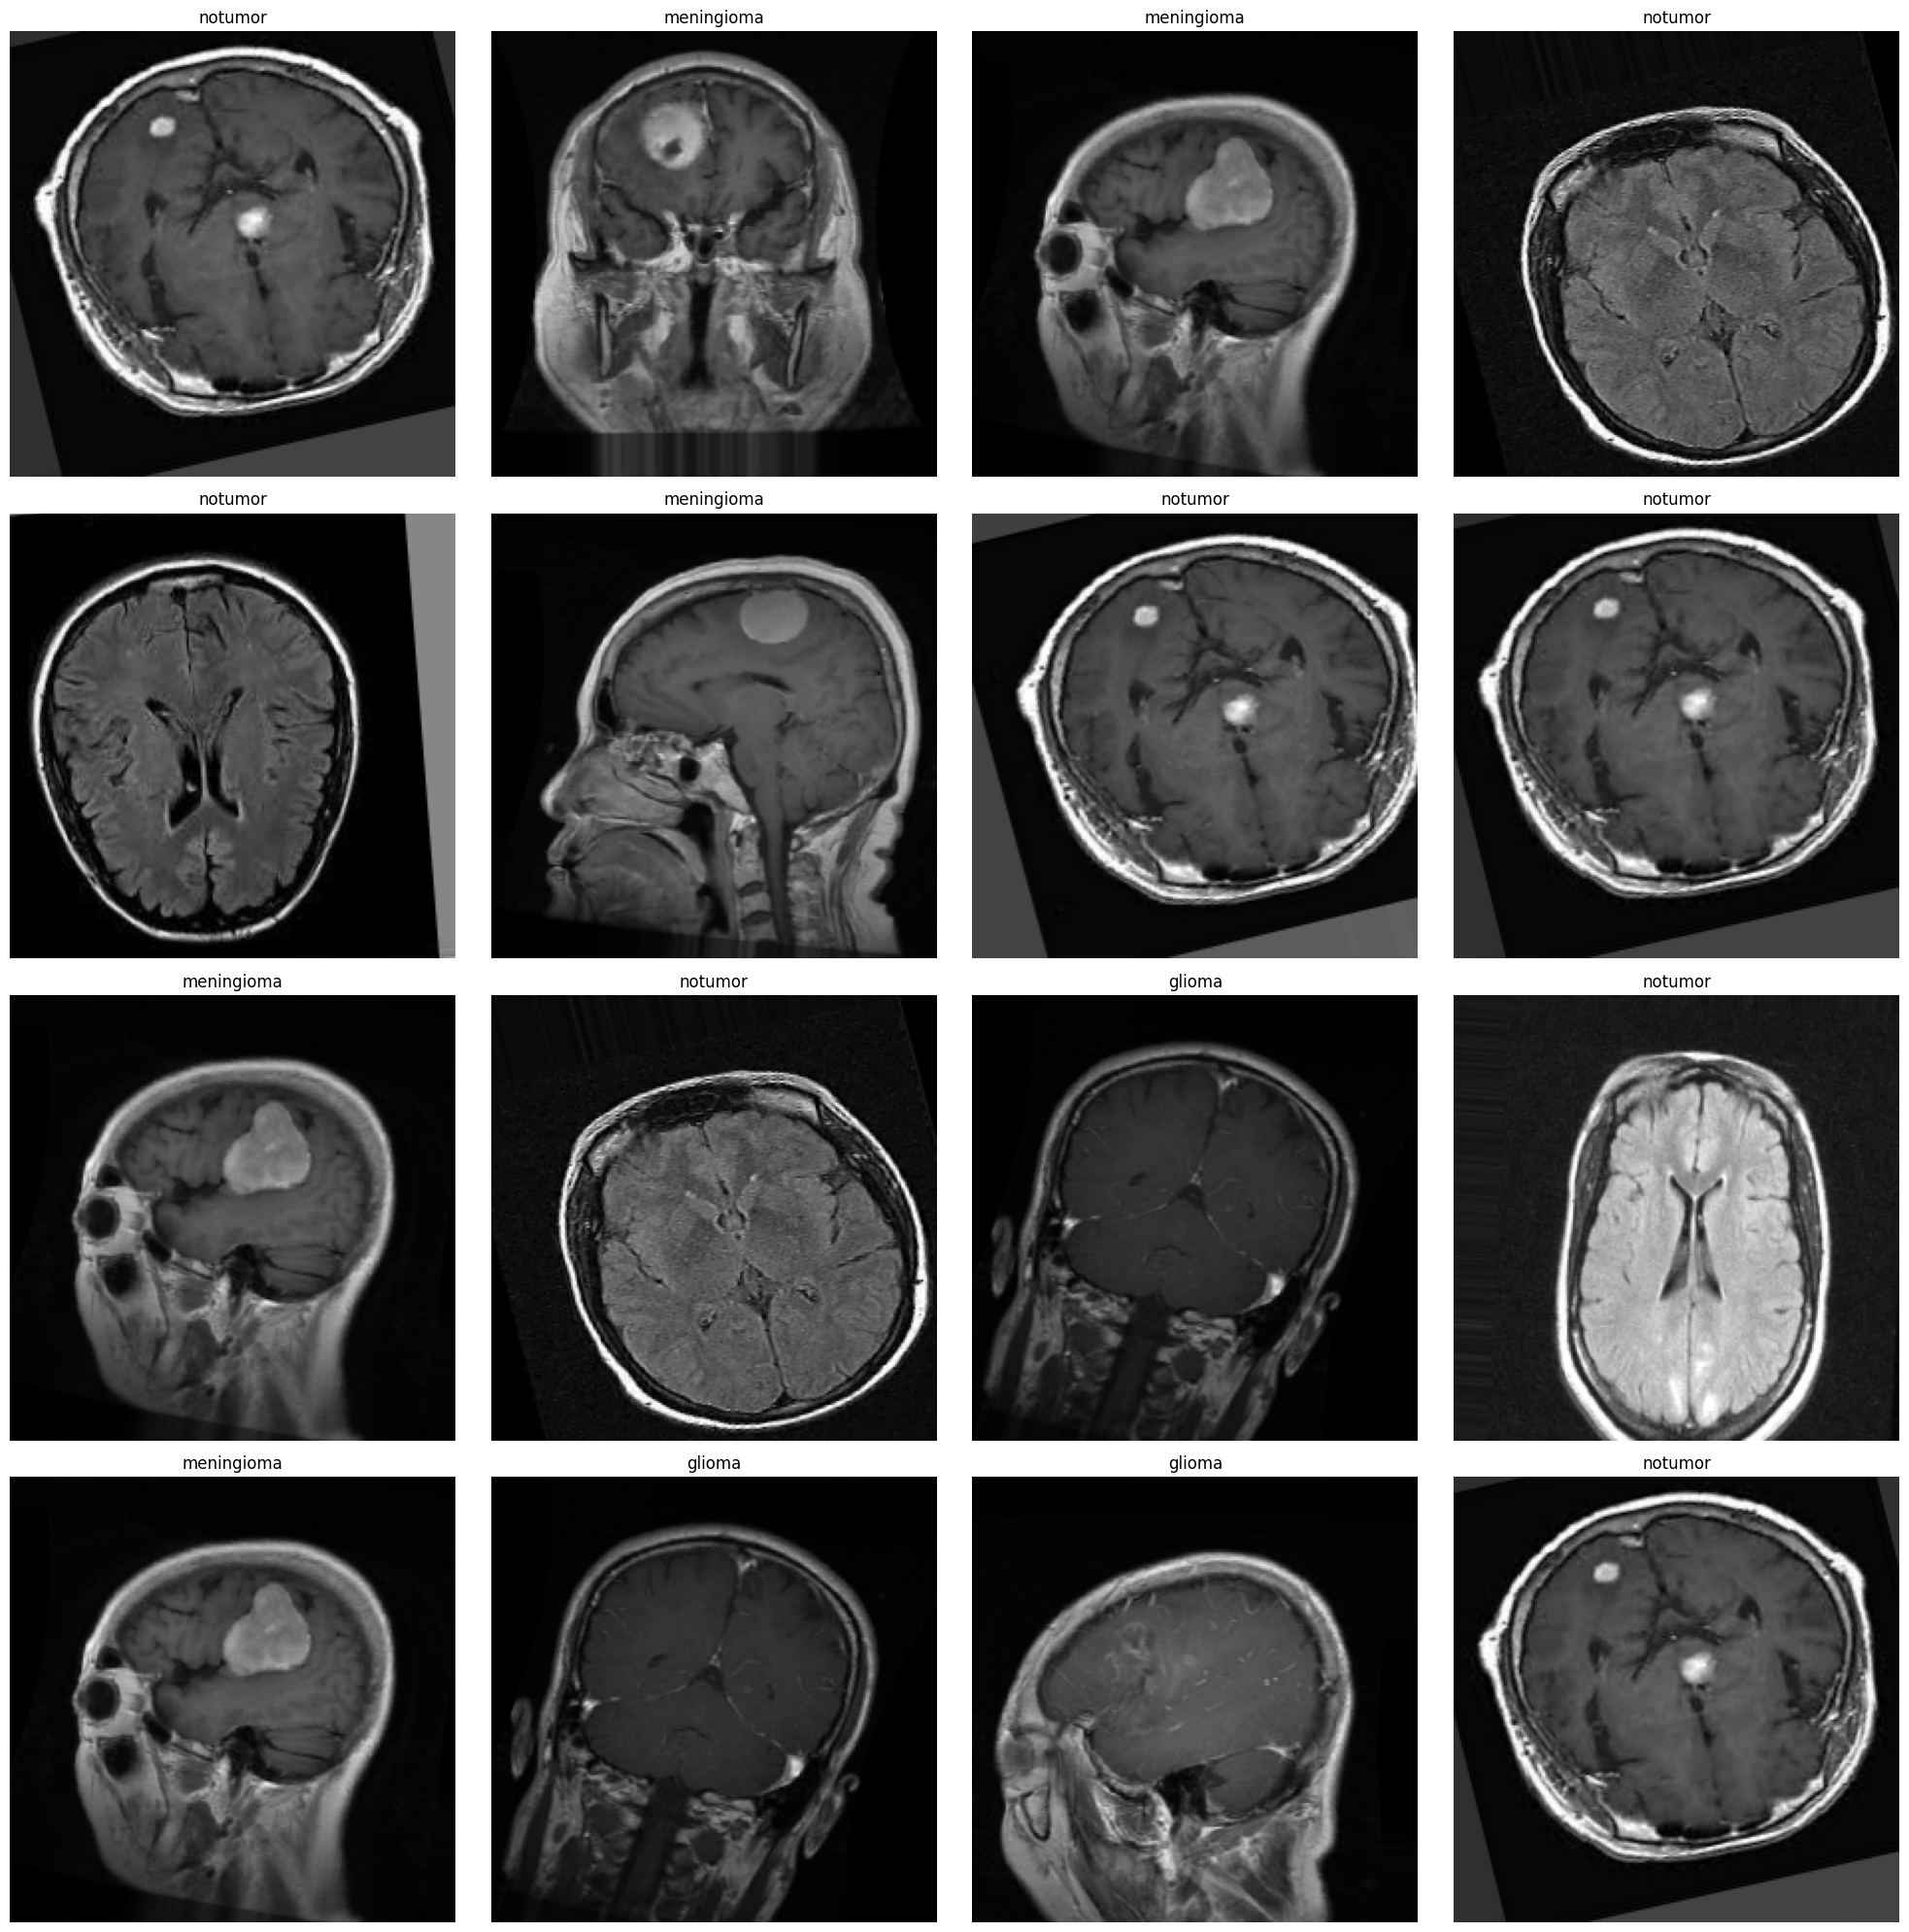

In [ ]:
class_dict = NewTraining_gen.class_indices
classes = list(class_dict.keys())
images, labels = next(NewTraining_gen)
plt.figure(figsize=(20, 20))
for n, i in enumerate(np.random.randint(0, len(images), 16)):
    plt.subplot(4, 4, n + 1)
    plt.imshow(images[i])
    class_index = np.argmax(labels[i])
    class_name = classes[class_index]
    plt.title(class_name)
    plt.axis("off")
plt.tight_layout()
plt.show()

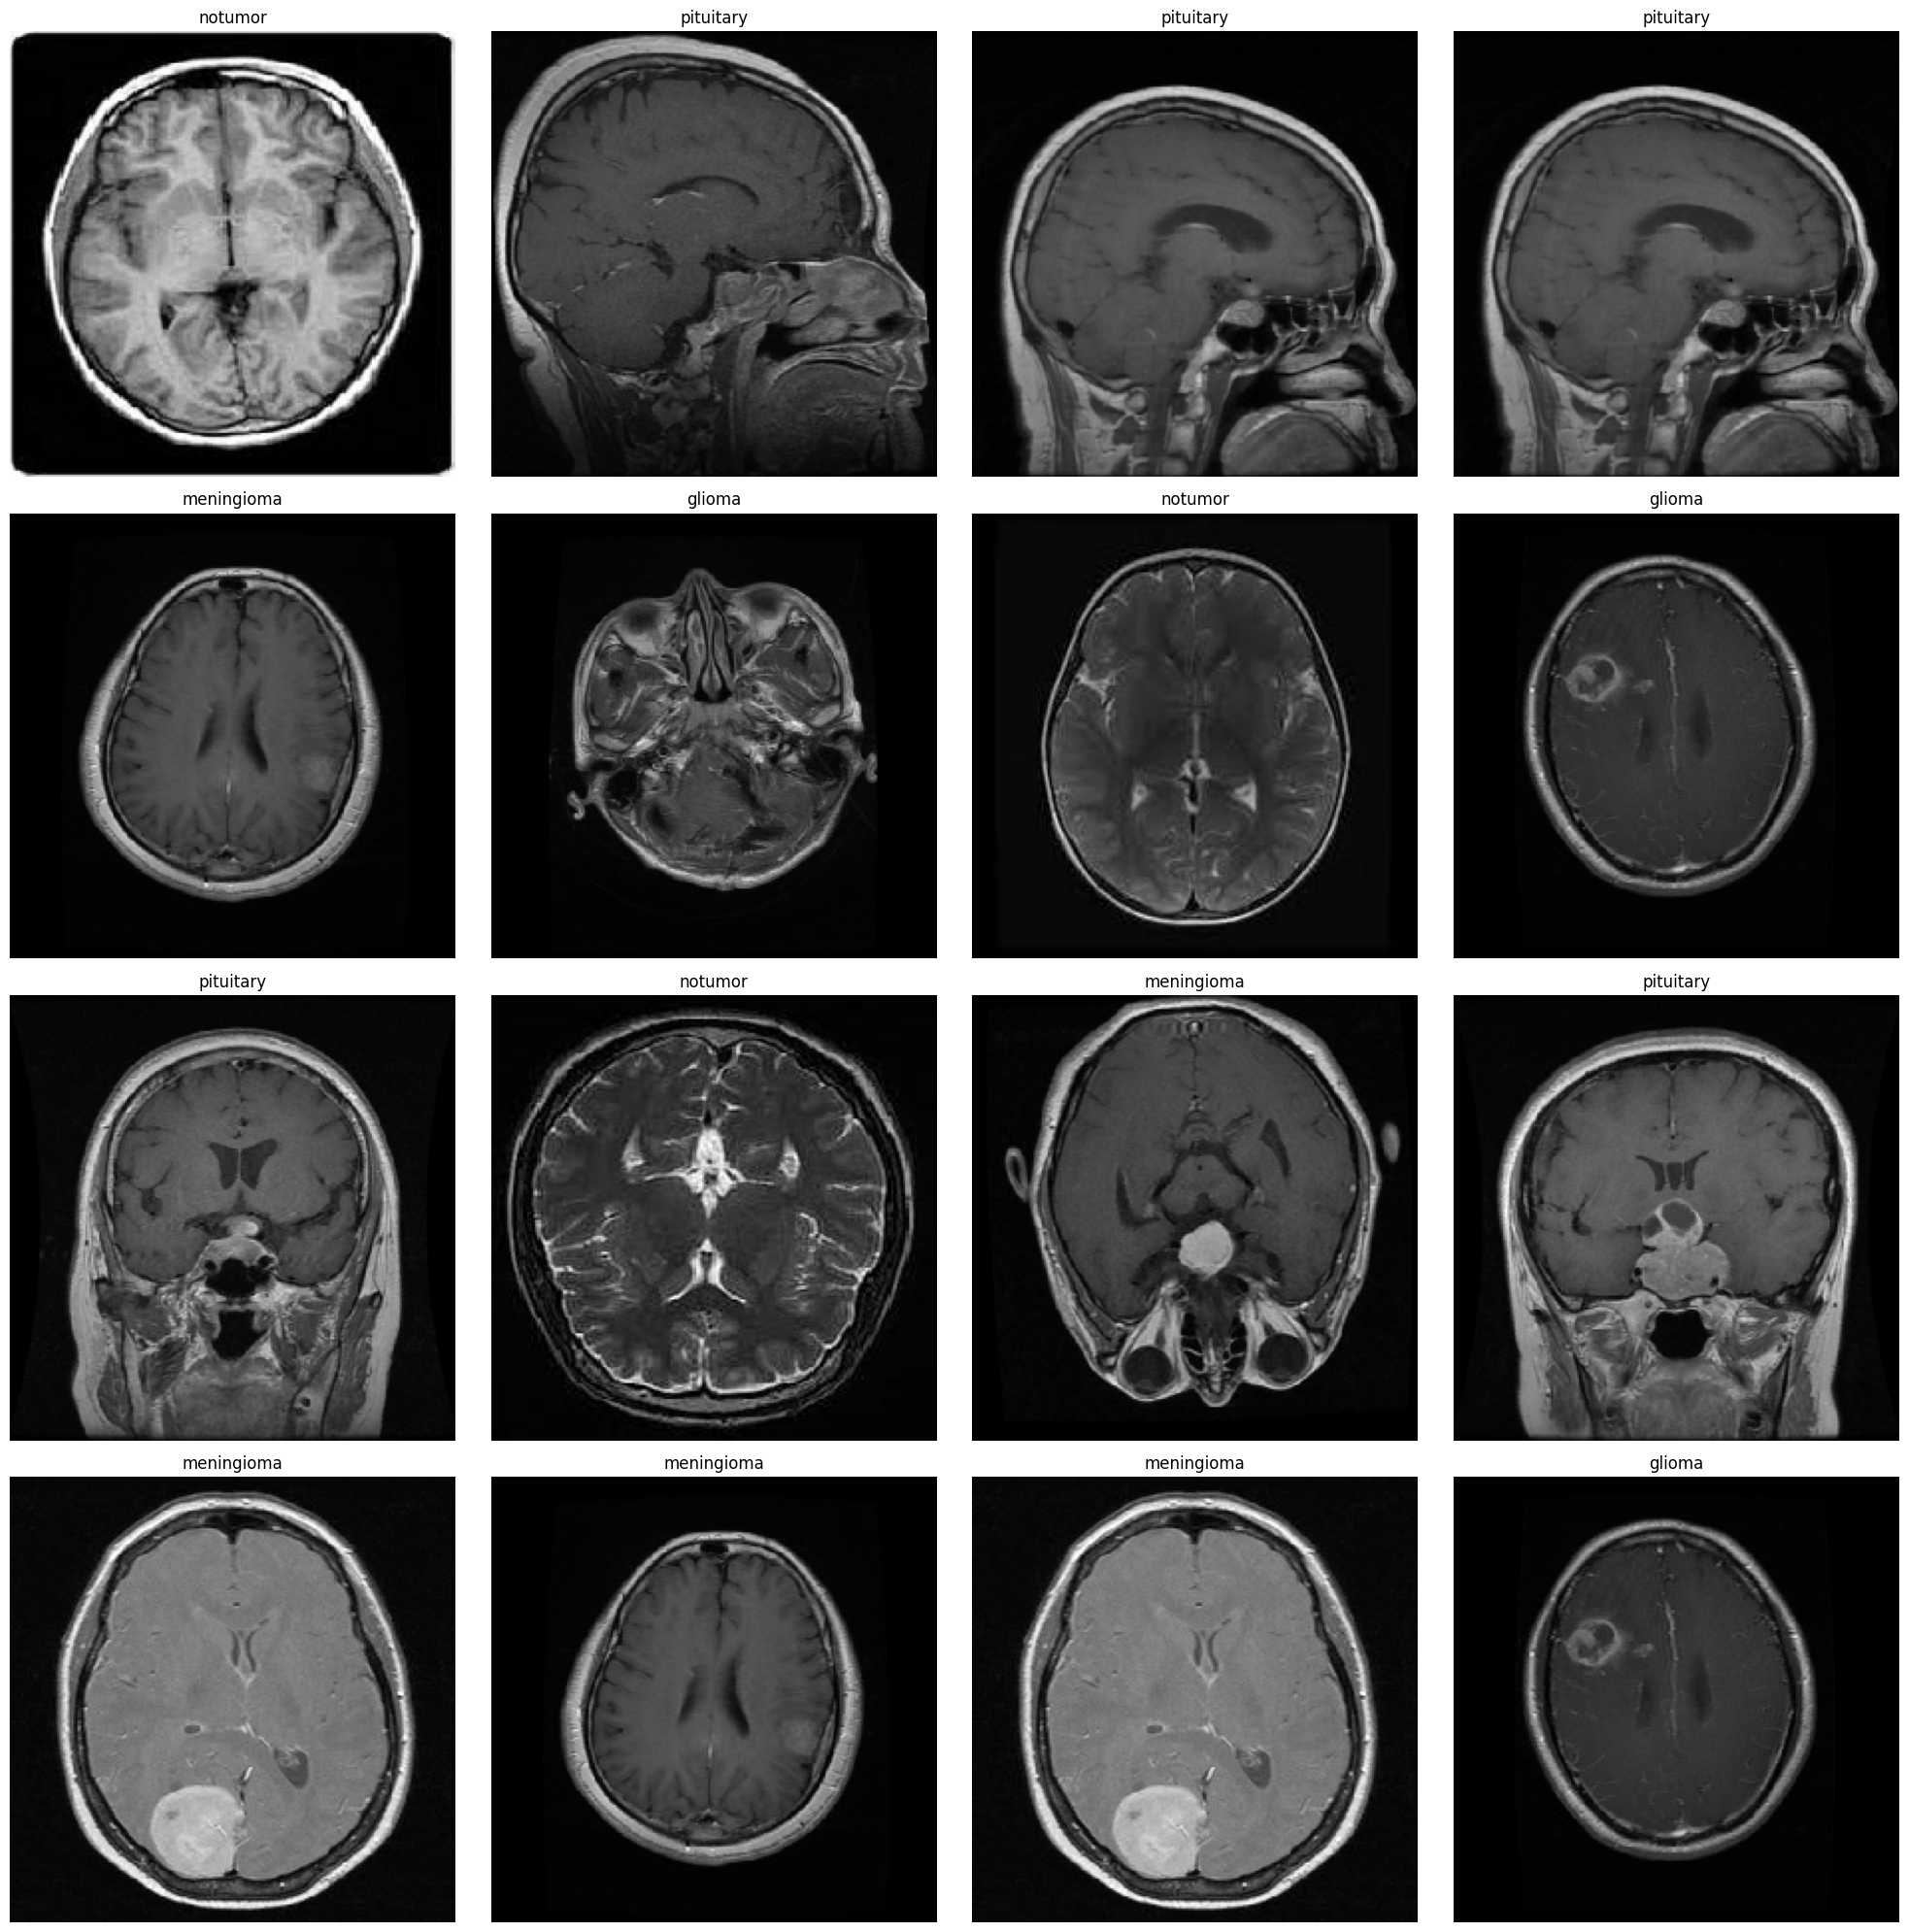

In [ ]:
class_dict = NewValiding_gen.class_indices
classes = list(class_dict.keys())
images, labels = next(NewValiding_gen)
plt.figure(figsize=(20, 20))
for n, i in enumerate(np.random.randint(0, len(images), 16)):
    plt.subplot(4, 4, n + 1)
    plt.imshow(images[i])
    class_index = np.argmax(labels[i])
    class_name = classes[class_index]
    plt.title(class_name)
    plt.axis("off")
plt.tight_layout()
plt.show()

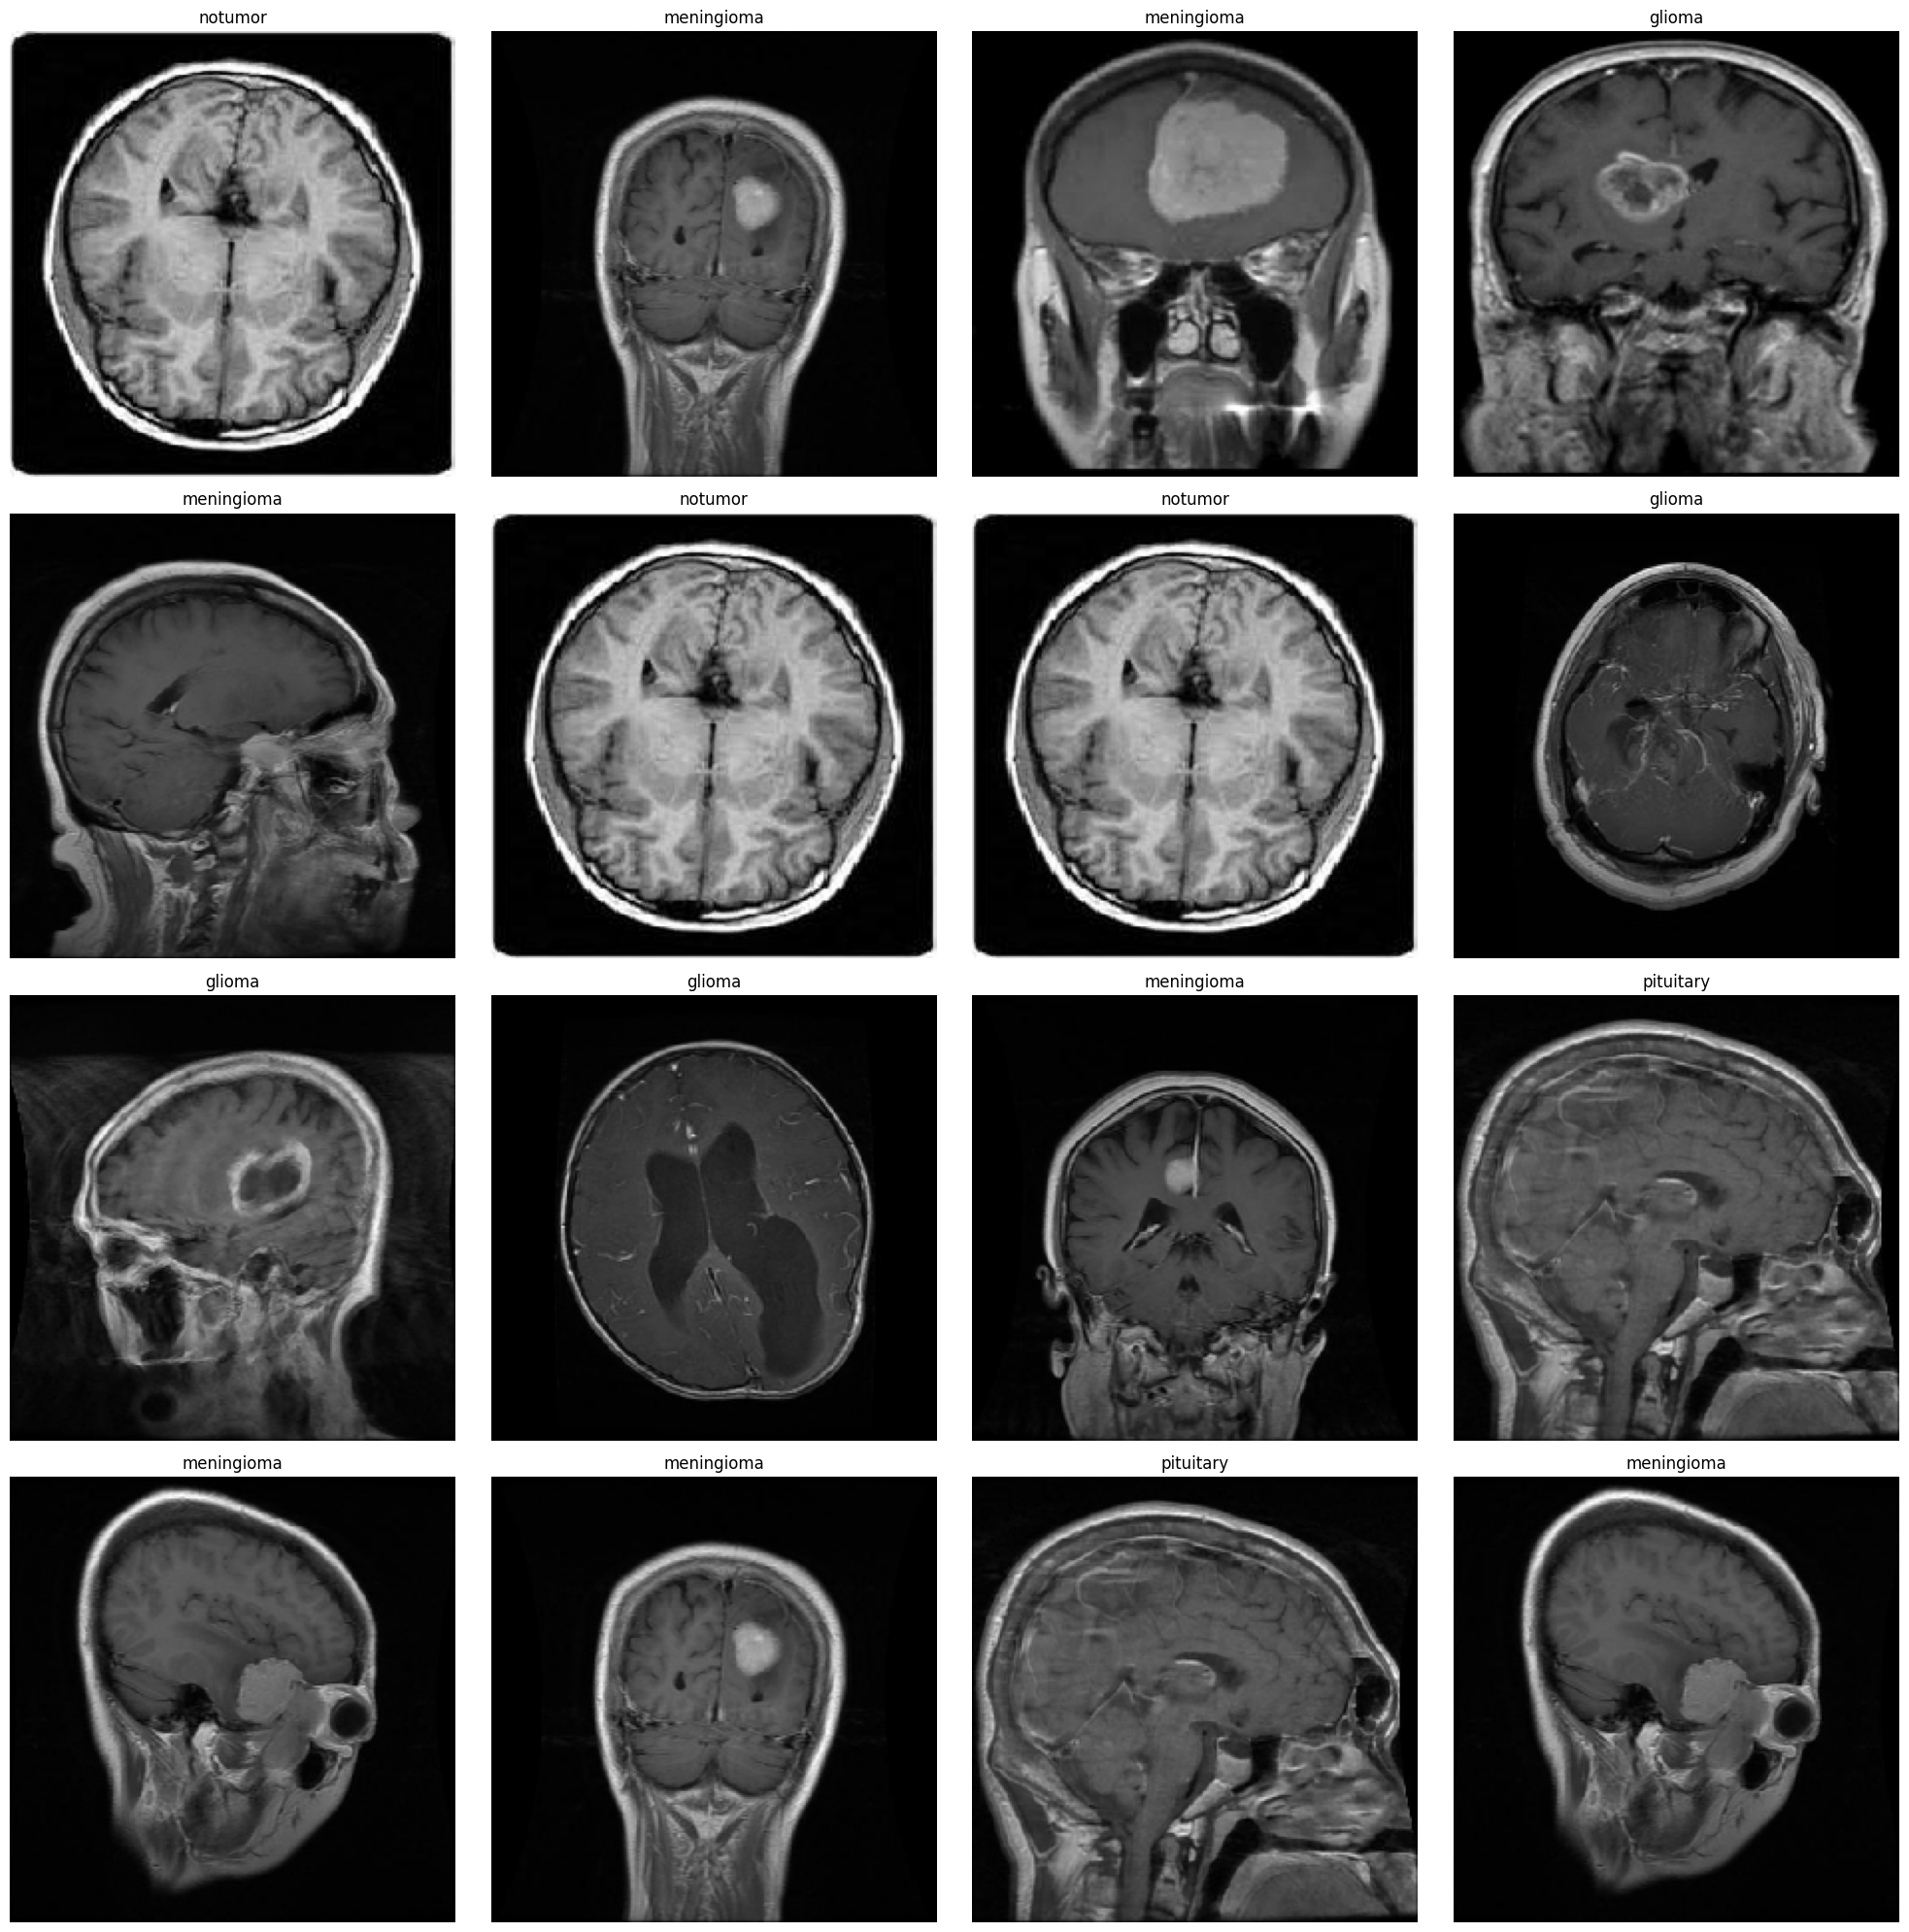

In [ ]:
class_dict = NewTesting_gen.class_indices
classes = list(class_dict.keys())
images, labels = next(NewTesting_gen)
plt.figure(figsize=(20, 20))
for n, i in enumerate(np.random.randint(0, len(images), 16)):
    plt.subplot(4, 4, n + 1)
    plt.imshow(images[i])
    class_index = np.argmax(labels[i])
    class_name = classes[class_index]
    plt.title(class_name)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
base_model = tf.keras.applications.Xception(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SHAPE,
    pooling="max"
)

In [ ]:
model = Sequential([
    base_model,
    Flatten(),
    Dropout(rate= 0.3),
    Dense(128, activation= 'relu'),
    Dropout(rate= 0.25),
    Dense(NUM_CLASSES, activation= 'softmax')
])

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 2048)           │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,124,268 (80.58 MB)

 Trainable params: 21,069,740 (80.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

In [ ]:
# early_stop = EarlyStopping(
#     monitor='val_loss',
#     patience=5,
#     restore_best_weights=True
# )

# reduce_lr = ReduceLROnPlateau(
#     monitor='val_loss',
#     factor=0.2,
#     patience=5,
#     verbose=1
# )

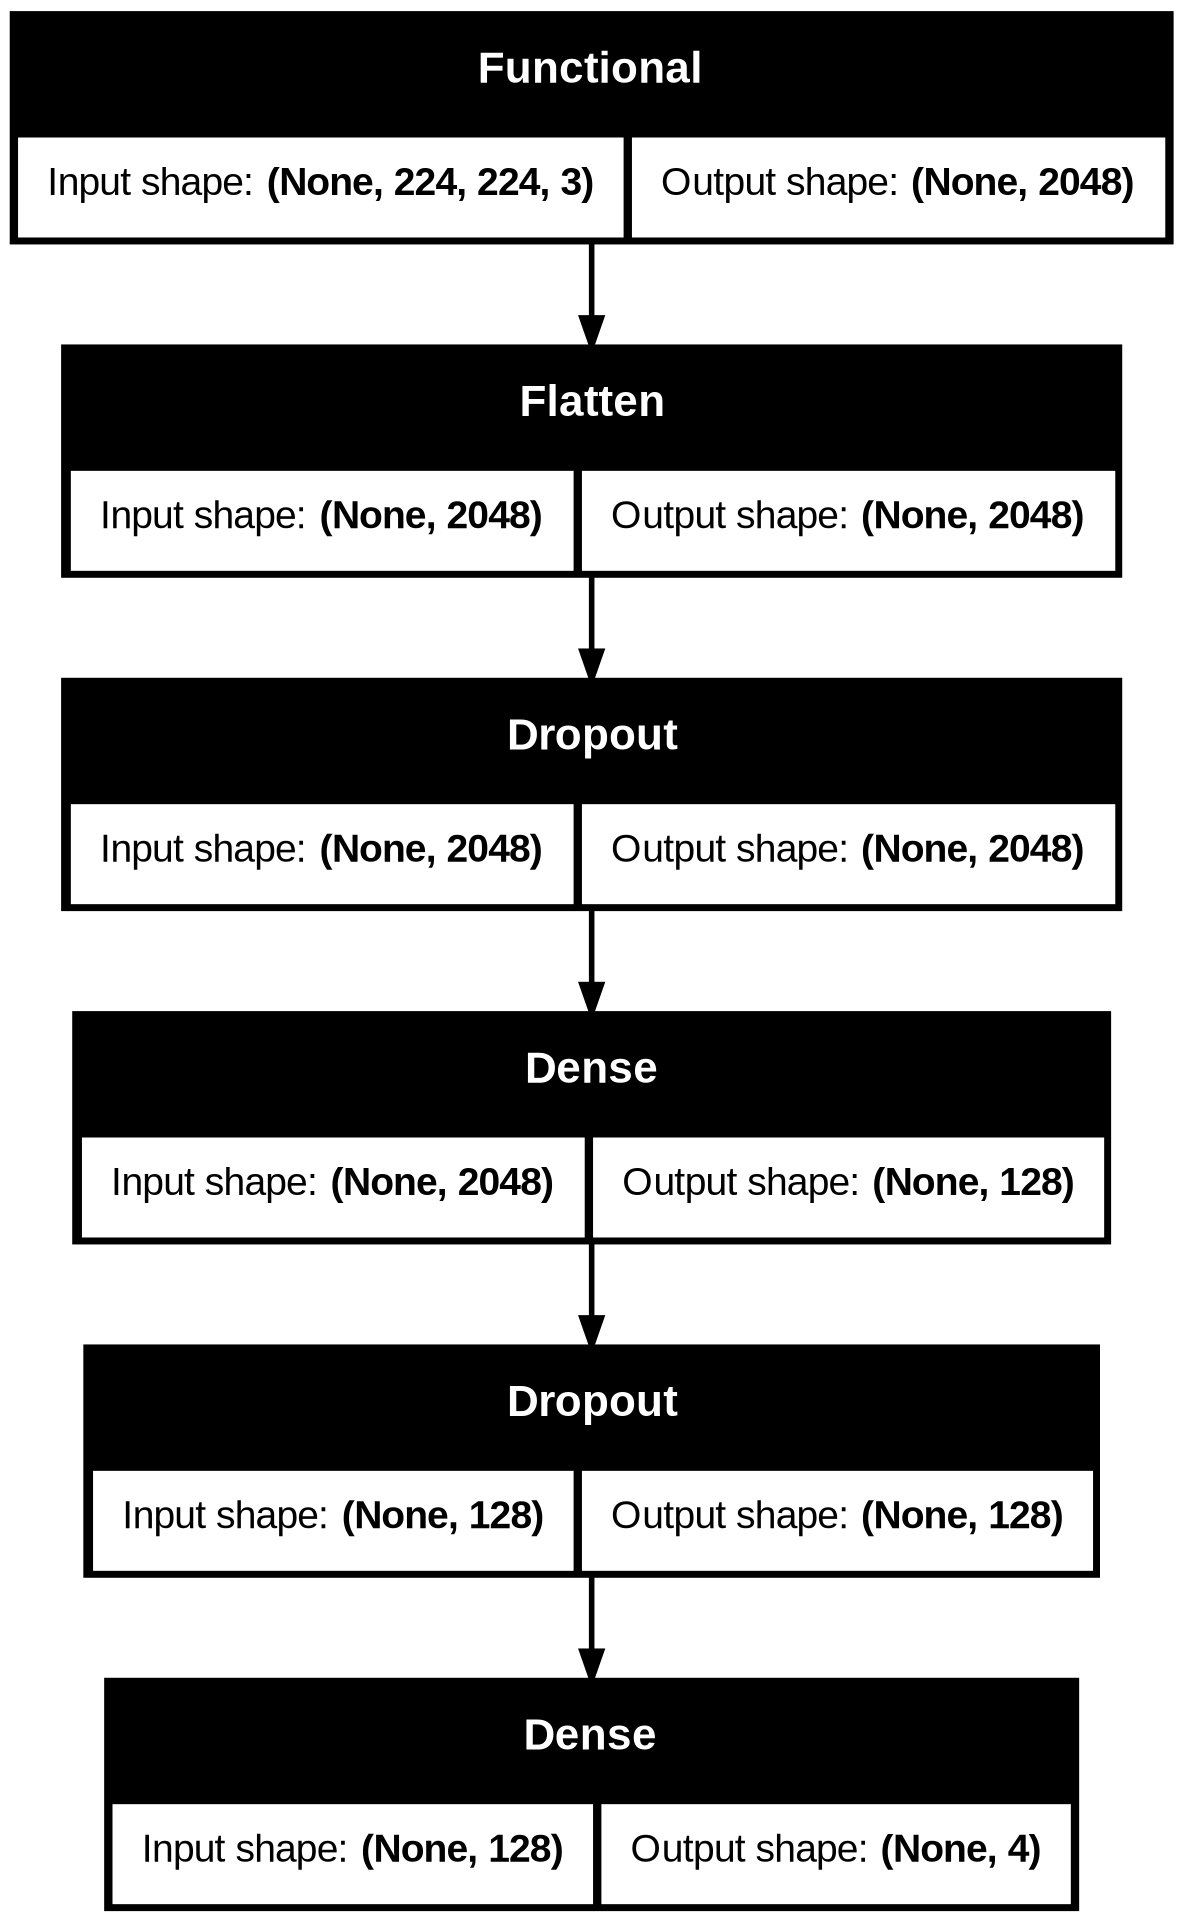

In [ ]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [ ]:
model.compile(Adamax(learning_rate= 0.0001),
              loss= 'categorical_crossentropy',
              metrics= ['accuracy',
                        Precision(),
                        Recall()])

In [ ]:
History = model.fit(
    NewTraining_gen,
    epochs=20,
    validation_data=NewValiding_gen,
)

Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 168s 731ms/step - accuracy: 0.7229 - loss: 0.7355 - precision_1: 0.8053 - recall_1: 0.6146 - val_accuracy: 0.6388 - val_loss: 0.9058 - val_precision_1: 0.6676 - val_recall_1: 0.6075
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 123s 700ms/step - accuracy: 0.8864 - loss: 0.3200 - precision_1: 0.9059 - recall_1: 0.8702 - val_accuracy: 0.7237 - val_loss: 0.7477 - val_precision_1: 0.7327 - val_recall_1: 0.7025
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 120s 686ms/step - accuracy: 0.9225 - loss: 0.2165 - precision_1: 0.9324 - recall_1: 0.9139 - val_accuracy: 0.8537 - val_loss: 0.4586 - val_precision_1: 0.8662 - val_recall_1: 0.8338
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 121s 688ms/step - accuracy: 0.9480 - loss: 0.1518 - precision_1: 0.9543 - recall_1: 0.9432 - val_accuracy: 0.9200 - val_loss: 0.3445 - val_precision_1: 0.9233 - val_recall_1: 0.9175
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 122s 693ms/step - accuracy: 0.9602 - loss: 0.1122 - precision_1: 0.9640 

In [ ]:
History.history.keys()

dict_keys(['accuracy', 'loss', 'precision_1', 'recall_1', 'val_accuracy', 'val_loss', 'val_precision_1', 'val_recall_1'])

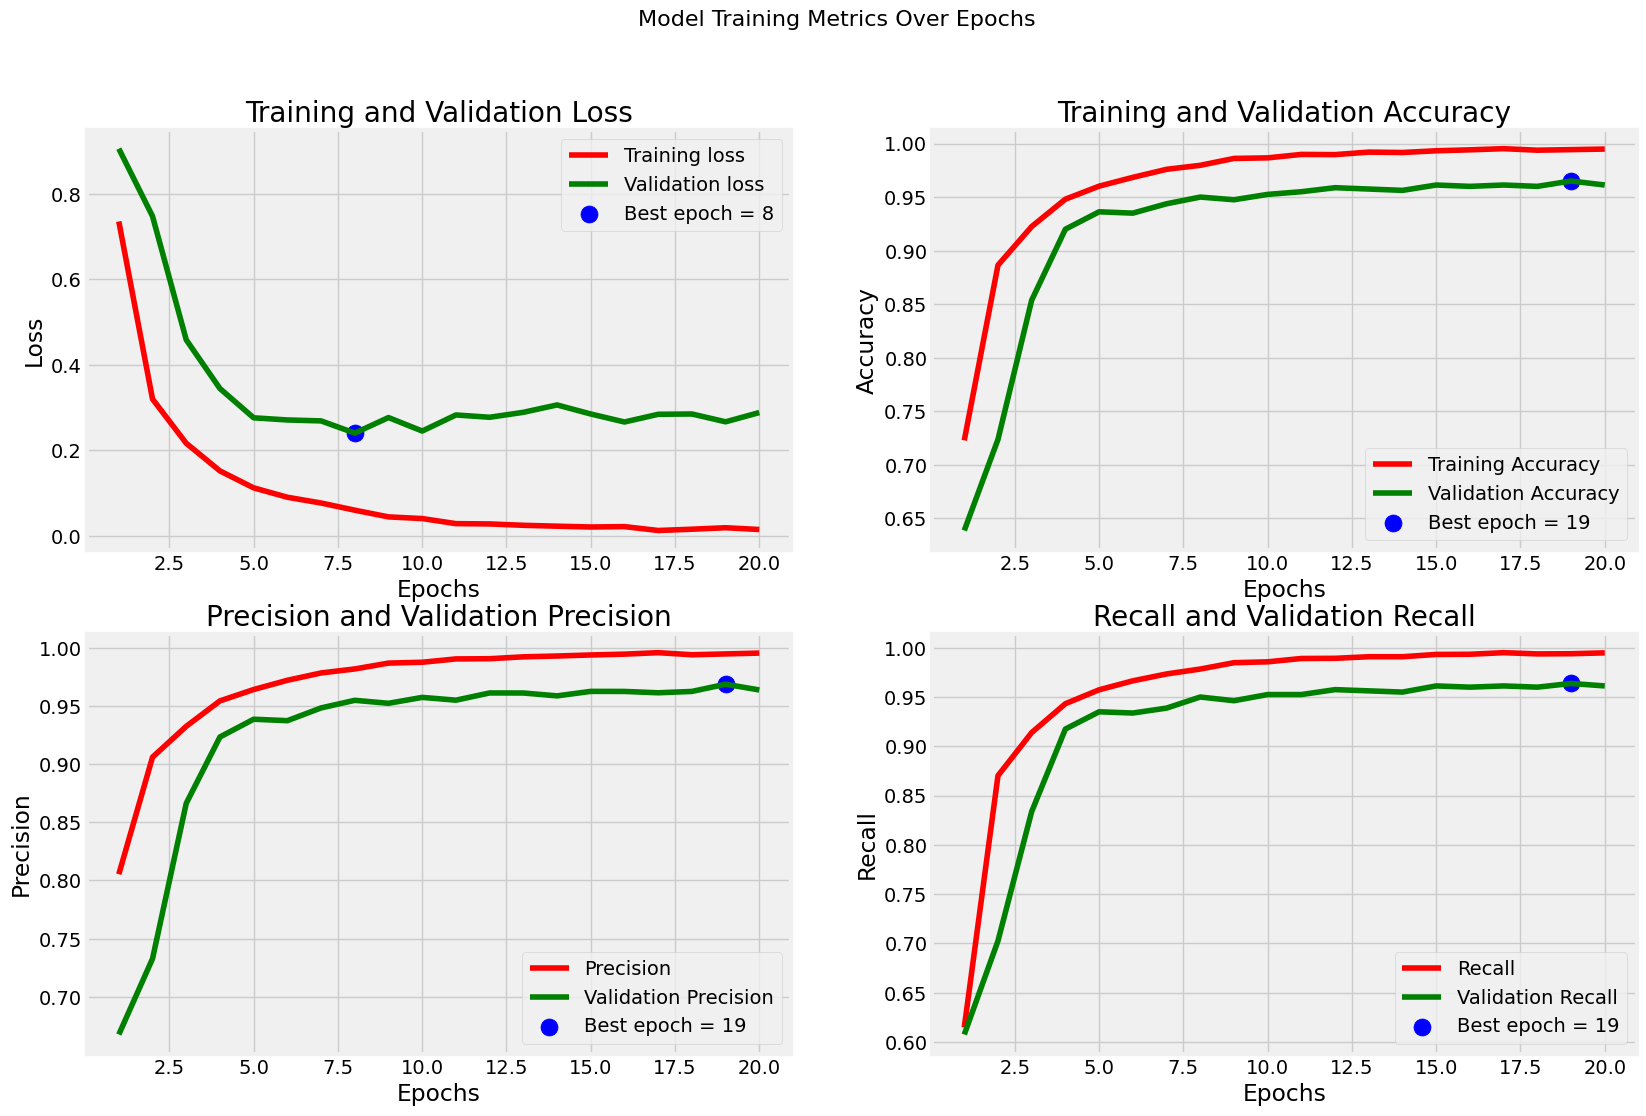

In [ ]:
tr_acc = History.history['accuracy']
tr_loss = History.history['loss']
tr_per = History.history['precision_1']
tr_recall = History.history['recall_1']
val_acc = History.history['val_accuracy']
val_loss = History.history['val_loss']
val_per = History.history['val_precision_1']
val_recall = History.history['val_recall_1']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
index_precision = np.argmax(val_per)
per_highest = val_per[index_precision]
index_recall = np.argmax(val_recall)
recall_highest = val_recall[index_recall]

Epochs = [i + 1 for i in range(len(tr_acc))]
loss_label = f'Best epoch = {str(index_loss + 1)}'
acc_label = f'Best epoch = {str(index_acc + 1)}'
per_label = f'Best epoch = {str(index_precision + 1)}'
recall_label = f'Best epoch = {str(index_recall + 1)}'


plt.figure(figsize=(20, 12))
plt.style.use('fivethirtyeight')


plt.subplot(2, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label='Training loss')
plt.plot(Epochs, val_loss, 'g', label='Validation loss')
plt.scatter(index_loss + 1, val_lowest, s=150, c='blue', label=loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label='Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label='Validation Accuracy')
plt.scatter(index_acc + 1, acc_highest, s=150, c='blue', label=acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(Epochs, tr_per, 'r', label='Precision')
plt.plot(Epochs, val_per, 'g', label='Validation Precision')
plt.scatter(index_precision + 1, per_highest, s=150, c='blue', label=per_label)
plt.title('Precision and Validation Precision')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(Epochs, tr_recall, 'r', label='Recall')
plt.plot(Epochs, val_recall, 'g', label='Validation Recall')
plt.scatter(index_recall + 1, recall_highest, s=150, c='blue', label=recall_label)
plt.title('Recall and Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.suptitle('Model Training Metrics Over Epochs', fontsize=16)
plt.show()

In [ ]:
train_score = model.evaluate(NewTraining_gen, verbose=1)
valid_score = model.evaluate(NewValiding_gen, verbose=1)
test_score = model.evaluate(NewTesting_gen, verbose=1)

print(f"Train Loss: {train_score[0]:.4f}")
print(f"Train Accuracy: {train_score[1]*100:.2f}%")
print('-' * 20)
print(f"Validation Loss: {valid_score[0]:.4f}")
print(f"Validation Accuracy: {valid_score[1]*100:.2f}%")
print('-' * 20)
print(f"Test Loss: {test_score[0]:.4f}")
print(f"Test Accuracy: {test_score[1]*100:.2f}%")


175/175 ━━━━━━━━━━━━━━━━━━━━ 93s 533ms/step - accuracy: 0.9989 - loss: 0.0036 - precision_1: 0.9989 - recall_1: 0.9987
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 156ms/step - accuracy: 0.9613 - loss: 0.2884 - precision_1: 0.9637 - recall_1: 0.9613
50/50 ━━━━━━━━━━━━━━━━━━━━ 230s 4s/step - accuracy: 0.9575 - loss: 0.3911 - precision_1: 0.9574 - recall_1: 0.9550
Train Loss: 0.0036
Train Accuracy: 99.89%
--------------------
Validation Loss: 0.2884
Validation Accuracy: 96.13%
--------------------
Test Loss: 0.3911
Test Accuracy: 95.75%


In [ ]:
# Reset test generator
NewTesting_gen.reset()

# Class names in the same order as class_indices
target_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Predictions
y_prob = model.predict(NewTesting_gen, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

# True labels
y_true = NewTesting_gen.classes

# Classification Report
print("Classification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=target_names
    )
)

50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step
Classification Report:
              precision    recall  f1-score   support

      glioma       1.00      0.83      0.91       200
  meningioma       0.89      1.00      0.94       200
     notumor       0.95      1.00      0.98       200
   pituitary       1.00      1.00      1.00       200

    accuracy                           0.96       800
   macro avg       0.96      0.96      0.96       800
weighted avg       0.96      0.96      0.96       800



In [ ]:
cm = confusion_matrix(y_true, y_pred)

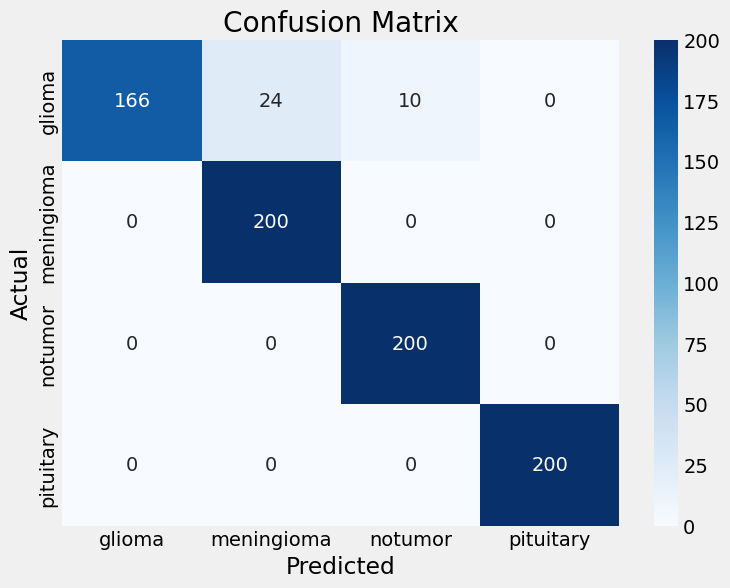

In [ ]:
# ------------------------------
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
model.save("brain_tumor_model.keras")

In [ ]:
import json

class_indices = {
    'glioma': 0,
    'meningioma': 1,
    'notumor': 2,
    'pituitary': 3
}

with open("class_indices.json", "w") as f:
    json.dump(class_indices, f, indent=4)

In [ ]:
class_names = list(class_indices.keys())

def predict(img_path):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((224, 224))
    img_array = np.asarray(img, dtype=np.float32)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    predictions = model.predict(img_array, verbose=0)[0]
    predicted_index = np.argmax(predictions)
    predicted_class = class_names[predicted_index]
    confidence = float(predictions[predicted_index]) * 100
    return predicted_class, confidence

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("brain_tumor_model.keras")


In [ ]:
result, confidence = predict("/content/Te-aug-me_1.jpg")

print("Prediction:", result)
print("Confidence:", f"{confidence:.2f}%")

Prediction: meningioma
Confidence: 100.00%


In [ ]:
result, confidence = predict("/content/Te-gl_1.jpg")

print("Prediction:", result)
print("Confidence:", f"{confidence:.2f}%")

Prediction: glioma
Confidence: 64.70%


In [ ]:
result, confidence = predict("/content/Te-no_1.jpg")

print("Prediction:", result)
print("Confidence:", f"{confidence:.2f}%")

Prediction: notumor
Confidence: 56.62%


In [ ]:
result, confidence = predict("/content/Te-pi_1.jpg")

print("Prediction:", result)
print("Confidence:", f"{confidence:.2f}%")

Prediction: pituitary
Confidence: 100.00%
